Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

Loading Data

In [2]:
df = pd.read_csv("realistic_migraine_data.csv").sample(frac=1, random_state=42)

X = df.drop("Migraine_Score", axis=1)
y = df["Migraine_Score"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

Training the LightGBM model:

In [3]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
lgb_model.fit(X_train, y_train)

pred = lgb_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000103 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 155
[LightGBM] [Info] Number of data points in the train set: 7000, number of used features: 14
[LightGBM] [Info] Start training from score 53.218830
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

Evaluation

In [4]:
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²  :", r2_score(y_test, pred))

MAE : 2.0507449053991005
RMSE: 2.5846350639872666
R²  : 0.978394404985524


Visualization

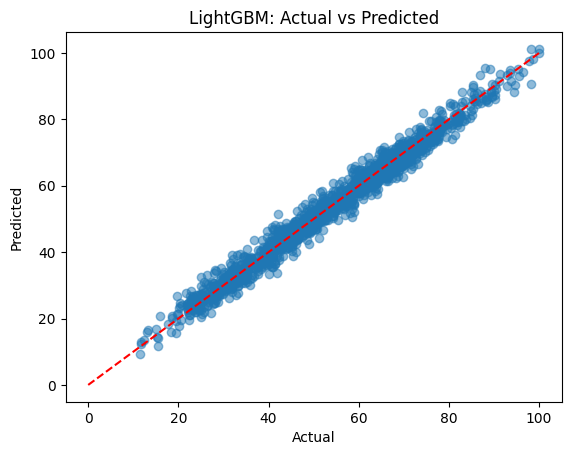

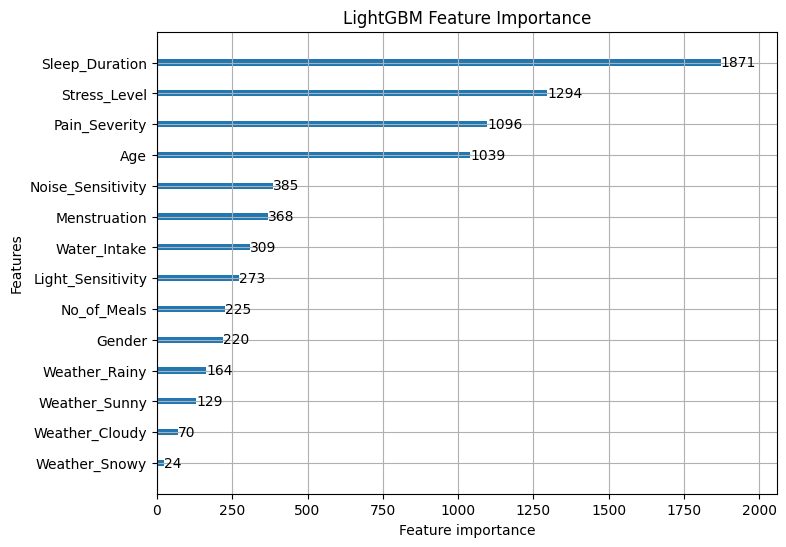

In [5]:
plt.scatter(y_test, pred, alpha=0.5)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LightGBM: Actual vs Predicted")
plt.show()

lgb.plot_importance(lgb_model, max_num_features=14, figsize=(8,6))
plt.title("LightGBM Feature Importance")
plt.show()